/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_date

FORECAST ACCURACY

Exponential Smoothing
MAE: 246.1742880115098
MSE: 125914.77476482288
RMSE: 354.8447192291621

ARIMA
MAE: 334.8099440502158
MSE: 210897.0194988618
RMSE: 459.2352550696231


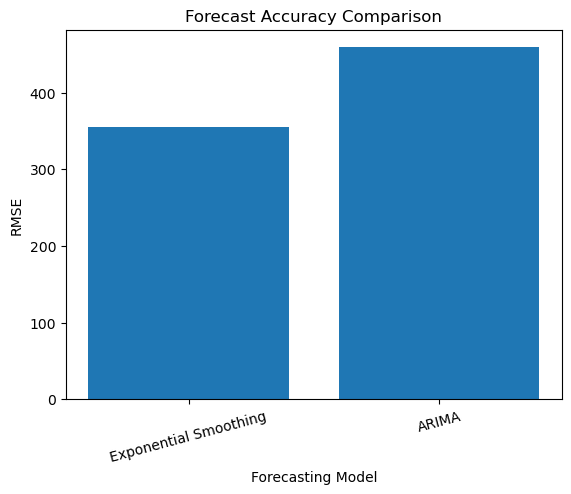

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load Dataset
df = pd.read_csv("blood_donation_registry_ml_ready.csv")

# Convert date
df["last_donation_date"] = pd.to_datetime(df["last_donation_date"])

# Monthly donor activity
monthly_data = df.groupby(
    df["last_donation_date"].dt.to_period("M")
)["donor_id"].nunique()

monthly_data.index = monthly_data.index.to_timestamp()

# Train-Test Split
train_size = int(len(monthly_data) * 0.8)

train = monthly_data.iloc[:train_size]
test = monthly_data.iloc[train_size:]

# Exponential Smoothing
model_es = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None
)

fit_es = model_es.fit()

forecast_es = fit_es.forecast(len(test))

# ARIMA
model_arima = ARIMA(
    train,
    order=(1, 1, 1)
)

fit_arima = model_arima.fit()

forecast_arima = fit_arima.forecast(len(test))

# Forecast Accuracy
mae_es = mean_absolute_error(test, forecast_es)
mse_es = mean_squared_error(test, forecast_es)
rmse_es = np.sqrt(mse_es)

mae_arima = mean_absolute_error(test, forecast_arima)
mse_arima = mean_squared_error(test, forecast_arima)
rmse_arima = np.sqrt(mse_arima)

print("FORECAST ACCURACY")

print("\nExponential Smoothing")
print("MAE:", mae_es)
print("MSE:", mse_es)
print("RMSE:", rmse_es)

print("\nARIMA")
print("MAE:", mae_arima)
print("MSE:", mse_arima)
print("RMSE:", rmse_arima)

# Comparison Chart
models = ["Exponential Smoothing", "ARIMA"]
rmse_values = [rmse_es, rmse_arima]

plt.bar(models, rmse_values)
plt.title("Forecast Accuracy Comparison")
plt.xlabel("Forecasting Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()